In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from scipy.stats import hmean

In [3]:
data = pd.read_excel('training_progress.xlsx', header=0)

In [4]:
# Function to compute the average of the numbers in the string
def compute_average(score_string):
    numbers = list(map(float, score_string.strip("[]").split()))  # Extract numbers and convert to int
    return hmean(numbers)  # Compute the mean

# Apply the function to the column
data["Train Label-Harm-Average F1 Score"] = data["Train Label F1 Scores"].apply(compute_average)
data["Val Label-Harm-Average F1 Score"] = data["Val Label F1 Scores"].apply(compute_average)

data.head(5)

AttributeError: 'float' object has no attribute 'strip'

In [ ]:
reset_epochs = [6, 11, 17, 23, 29]

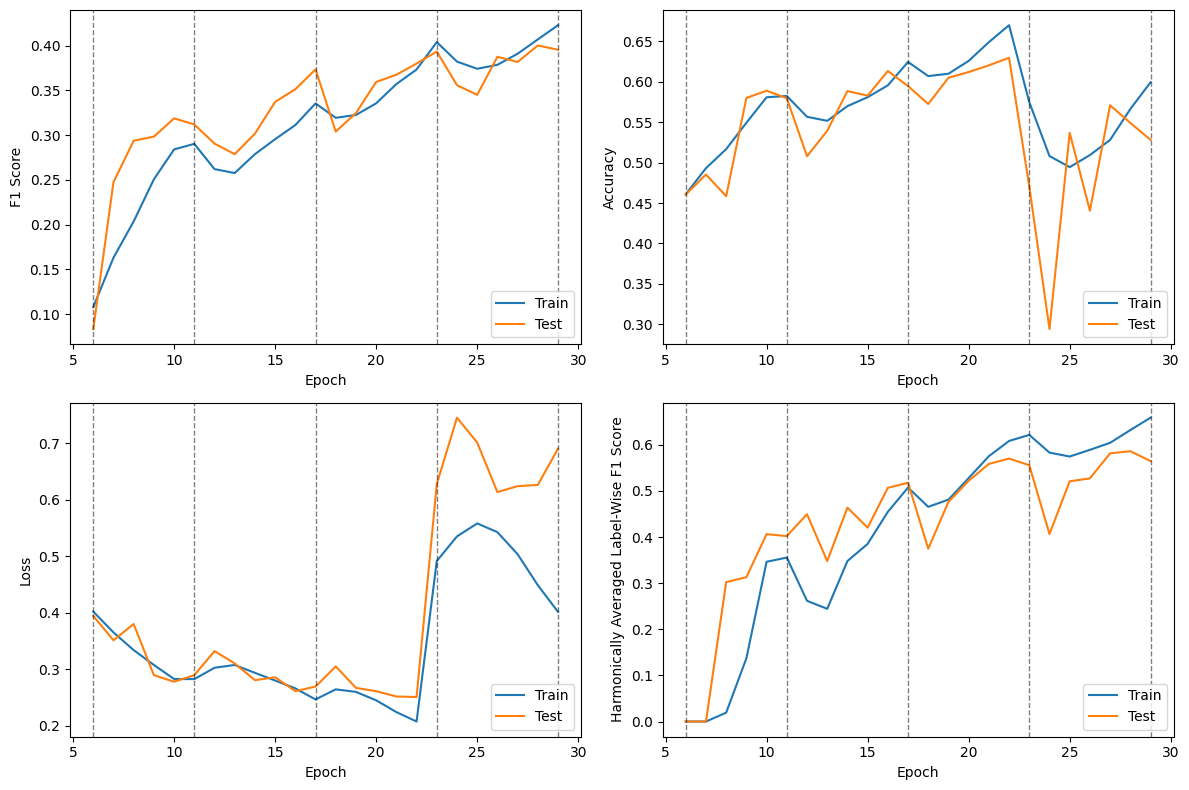

In [ ]:
fig, ax = plt.subplots(2, 2, figsize = (12, 8))

ax[0,0].plot(data['Epoch'], data['Train Avg F1 Score'], label = 'Train')
ax[0,0].plot(data['Epoch'], data['Val Avg F1 Score'], label = 'Test')
ax[0,0].set_xlabel('Epoch')
ax[0,0].set_ylabel('F1 Score')
ax[0,0].legend(loc='lower right')

ax[0,1].plot(data['Epoch'], data['Train Accuracy'], label = 'Train')
ax[0,1].plot(data['Epoch'], data['Val Accuracy'], label = 'Test')
ax[0,1].set_xlabel('Epoch')
ax[0,1].set_ylabel('Accuracy')
ax[0,1].legend(loc='lower right')

ax[1,0].plot(data['Epoch'], data['Train loss'], label = 'Train')
ax[1,0].plot(data['Epoch'], data['Val Loss'], label = 'Test')
ax[1,0].set_xlabel('Epoch')
ax[1,0].set_ylabel('Loss')
ax[1,0].legend(loc='lower right')

ax[1,1].plot(data['Epoch'], data['Train Label-Harm-Average F1 Score'], label = 'Train')
ax[1,1].plot(data['Epoch'], data['Val Label-Harm-Average F1 Score'], label = 'Test')
ax[1,1].set_xlabel('Epoch')
ax[1,1].set_ylabel('Harmonically Averaged Label-Wise F1 Score')
ax[1,1].legend(loc='lower right')


for epoch in reset_epochs: 
    ax[0,0].axvline(epoch, color = 'k', linestyle = '--', alpha = 0.5, lw=1)
    ax[0,1].axvline(epoch, color = 'k', linestyle = '--', alpha = 0.5, lw=1)
    ax[1,0].axvline(epoch, color = 'k', linestyle = '--', alpha = 0.5, lw=1)
    ax[1,1].axvline(epoch, color = 'k', linestyle = '--', alpha = 0.5, lw=1)

fig.tight_layout()